In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
sudan=pd.read_csv("../data/processed_data/sudan_clean.csv")

In [11]:
ethiopia=pd.read_csv("../data/processed_data/ethiopia_clean.csv")
kenya=pd.read_csv("../data/processed_data/kenya_clean.csv")
nigeria=pd.read_csv("../data/processed_data/nigeria_clean.csv")
Tanzania=pd.read_csv("../data/processed_data/Tanzania_clean.csv")

In [12]:
df=pd.concat([ethiopia, kenya, sudan, nigeria, Tanzania], ignore_index=True)

In [13]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [14]:
df["country"].value_counts()

country
Ethiopia    4108
kenya       4108
Sudan       4108
Nigeria     4108
Tanzania    4108
Name: count, dtype: int64

In [16]:
monthly_T2M=(df.groupby(["country", "YEAR", "Month"])["T2M"].mean().reset_index())

In [18]:
monthly_T2M["date"] = pd.to_datetime(
    monthly_T2M["YEAR"].astype(str) + "-" +
    monthly_T2M["Month"].astype(str) + "-01"
)

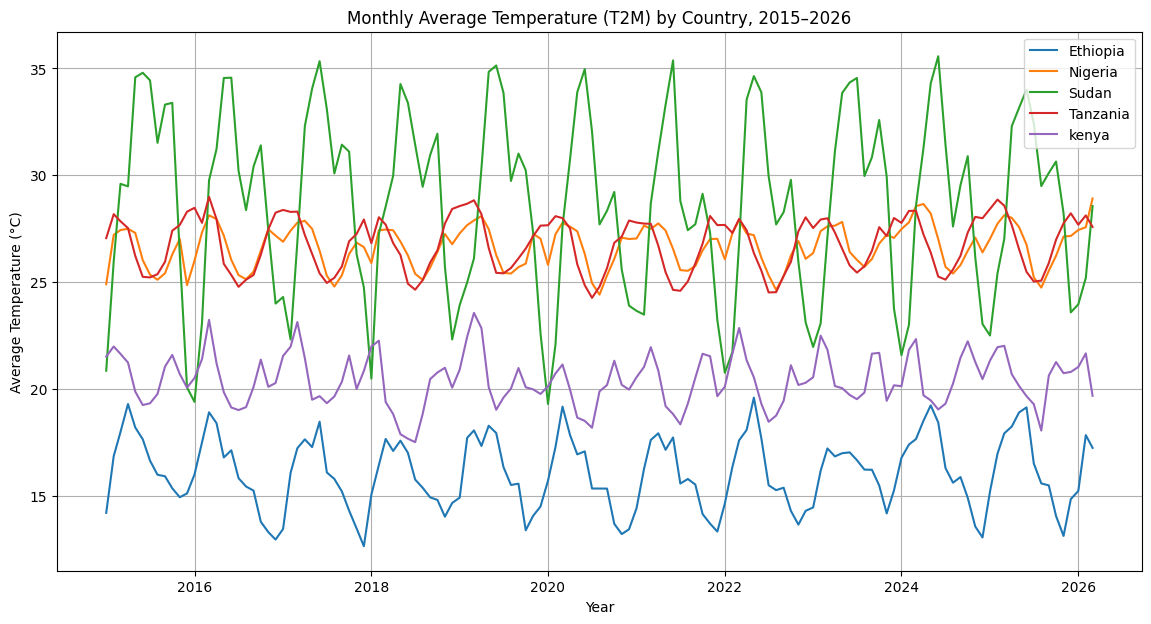

In [20]:

plt.figure(figsize=(14, 7))

for country in monthly_T2M["country"].unique():
    country_data = monthly_T2M[monthly_T2M["country"] == country]

    plt.plot(
        country_data["date"],
        country_data["T2M"],
        label=country
    )

plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Monthly Average Temperature (T2M) by Country, 2015–2026")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
t2m_summary = (
    df.groupby("country")["T2M"]
      .agg(["mean", "median", "std"])
      .reset_index()
)

t2m_summary[["mean", "median", "std"]] = (
    t2m_summary[["mean", "median", "std"]].round(2)
)

t2m_summary

,country,mean,median,std
0,Ethiopia,16.07,16.04,1.90
1,Nigeria,26.66,26.82,1.12
2,Sudan,28.76,29.16,4.68
3,Tanzania,26.80,26.99,1.33
4,kenya,20.43,20.36,1.44


<Figure size 1000x600 with 0 Axes>

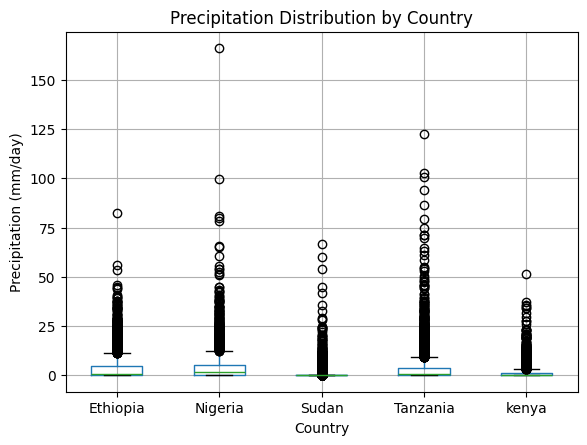

In [22]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="PRECTOTCORR",
    by="country"
)

plt.xlabel("Country")
plt.ylabel("Precipitation (mm/day)")
plt.title("Precipitation Distribution by Country")
plt.suptitle("")  # removes pandas' automatic title
plt.show()

In [23]:
precip_summary = (
    df.groupby("country")["PRECTOTCORR"]
      .agg(["mean", "median", "std"])
      .reset_index()
)

precip_summary[["mean", "median", "std"]] = (
    precip_summary[["mean", "median", "std"]].round(2)
)

precip_summary

,country,mean,median,std
0,Ethiopia,3.63,0.82,6.29
1,Nigeria,4.21,1.84,7.27
2,Sudan,0.64,0.00,3.06
3,Tanzania,3.74,0.64,8.00
4,kenya,1.47,0.38,3.18


In [24]:
df["extreme_heat"] = df["T2M_MAX"] > 35

In [25]:
heat_days = (
    df[df["extreme_heat"]]
    .groupby(["country", "YEAR"])
    .size()
    .reset_index(name="extreme_heat_days")
)

In [26]:
df["dry_day"] = df["PRECTOTCORR"] < 1

In [27]:
def longest_dry_spell(group):
    dry = group["dry_day"]

    groups = (dry != dry.shift()).cumsum()

    dry_runs = dry.groupby(groups).sum()

    return dry_runs.max() if not dry_runs.empty else 0

In [28]:
dry_spell = (
    df.groupby(["country", "YEAR"])
      .apply(longest_dry_spell)
      .reset_index(name="max_consecutive_dry_days")
)

In [29]:
heat_summary = (
    heat_days.groupby("country")["extreme_heat_days"]
    .mean()
    .reset_index()
)

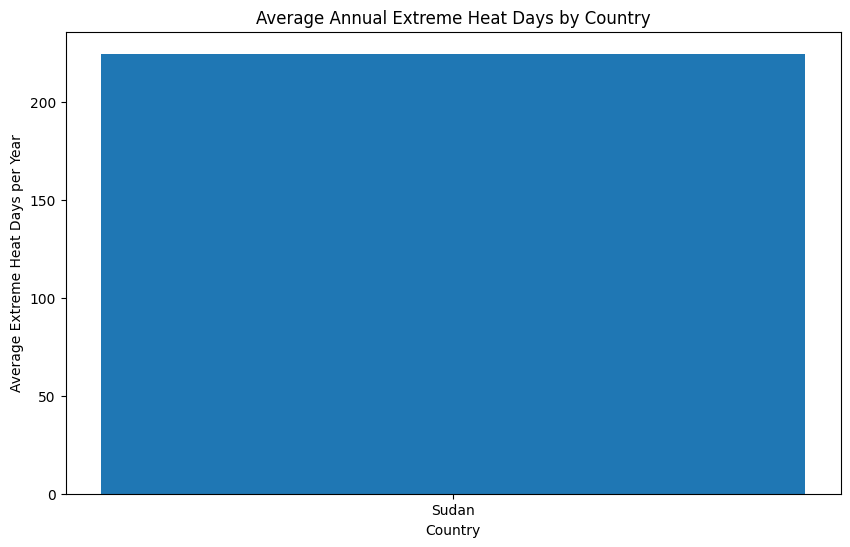

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    heat_summary["country"],
    heat_summary["extreme_heat_days"]
)

plt.xlabel("Country")
plt.ylabel("Average Extreme Heat Days per Year")
plt.title("Average Annual Extreme Heat Days by Country")
plt.show()

In [31]:
dry_summary = (
    dry_spell.groupby("country")["max_consecutive_dry_days"]
    .mean()
    .reset_index()
)

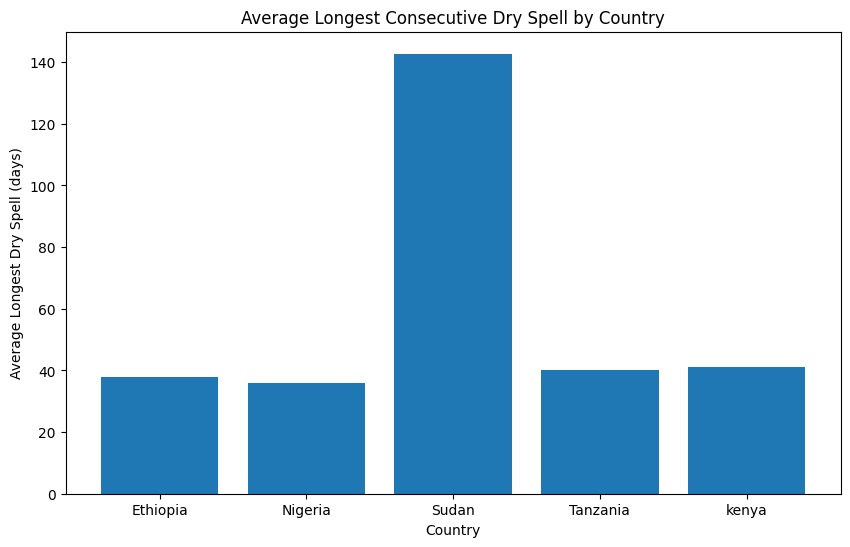

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    dry_summary["country"],
    dry_summary["max_consecutive_dry_days"]
)

plt.xlabel("Country")
plt.ylabel("Average Longest Dry Spell (days)")
plt.title("Average Longest Consecutive Dry Spell by Country")
plt.show()

In [33]:
from scipy.stats import f_oneway


In [41]:
df["country"].value_counts()

country
Ethiopia    4108
kenya       4108
Sudan       4108
Nigeria     4108
Tanzania    4108
Name: count, dtype: int64

In [40]:
df["country"] = df["country"].str.strip()

In [36]:
df.groupby("country")["T2M"].count()

country
Ethiopia    4108
Nigeria     4108
Sudan       4108
Tanzania    4108
kenya       4108
Name: T2M, dtype: int64

In [43]:

ethiopia_t2m = df[df["country"] == "Ethiopia"]["T2M"].dropna()
kenya_t2m = df[df["country"] == "kenya"]["T2M"].dropna()
sudan_t2m = df[df["country"] == "Sudan"]["T2M"].dropna()
tanzania_t2m = df[df["country"] == "Tanzania"]["T2M"].dropna()
Nigeria_t2m = df[df["country"] == "Nigeria"]["T2M"].dropna()

f_stat, p_value = f_oneway(
    ethiopia_t2m,
    kenya_t2m,
    sudan_t2m,
    tanzania_t2m,
    Nigeria_t2m
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 18938.745697069917
p-value: 0.0


### One-Way ANOVA

A one-way ANOVA was performed to test whether mean T2M differs across Ethiopia, Kenya, Sudan, Tanzania, and Nigeria.

The test produced an **F-statistic of 18,938.75** and a **p-value effectively equal to 0**. Since the p-value is far below the 0.05 significance level, the null hypothesis that all five countries have the same mean T2M is rejected.

This indicates that there is **statistically significant evidence of differences in mean temperature across the five countries**.

The ANOVA shows that at least one country's mean T2M differs from the others, but it does not identify which specific countries differ. A post-hoc test such as Tukey's HSD would be required to determine the pairwise differences.


In [44]:
vulnerability_summary = pd.DataFrame({
    "country": [
        "Ethiopia",
        "kenya",
        "Sudan",
        "Nigeria",
        "Tanzania"
    ],

    "mean_T2M": [
        t2m_summary.loc[t2m_summary["country"] == "Ethiopia", "mean"].iloc[0],
        t2m_summary.loc[t2m_summary["country"] == "kenya", "mean"].iloc[0],
        t2m_summary.loc[t2m_summary["country"] == "Sudan", "mean"].iloc[0],
        t2m_summary.loc[t2m_summary["country"] == "Nigeria", "mean"].iloc[0],
        t2m_summary.loc[t2m_summary["country"] == "Tanzania", "mean"].iloc[0]
    ]
})

In [47]:
heat_days = (
    df.groupby(["country", "YEAR"])["extreme_heat"]
      .sum()
      .reset_index(name="extreme_heat_days")
)

In [48]:
heat_summary = (
    heat_days.groupby("country")["extreme_heat_days"]
    .mean()
    .reset_index()
)

In [49]:
print(heat_summary)

    country  extreme_heat_days
0  Ethiopia                0.0
1   Nigeria                0.0
2     Sudan              224.5
3  Tanzania                0.0
4     kenya                0.0


In [50]:
print("T2M:")
print(t2m_summary["country"].tolist())

print("\nPrecipitation:")
print(precip_summary["country"].tolist())

print("\nHeat:")
print(heat_summary["country"].tolist())

print("\nDry spell:")
print(dry_summary["country"].tolist())

T2M:
['Ethiopia', 'Nigeria', 'Sudan', 'Tanzania', 'kenya']

Precipitation:
['Ethiopia', 'Nigeria', 'Sudan', 'Tanzania', 'kenya']

Heat:
['Ethiopia', 'Nigeria', 'Sudan', 'Tanzania', 'kenya']

Dry spell:
['Ethiopia', 'Nigeria', 'Sudan', 'Tanzania', 'kenya']


In [51]:
vulnerability_summary = pd.merge(
    t2m_summary,
    precip_summary,
    on="country",
    suffixes=("_T2M", "_precipitation")
)

vulnerability_summary = vulnerability_summary.merge(
    heat_summary,
    on="country"
)

vulnerability_summary = vulnerability_summary.merge(
    dry_summary,
    on="country"
)

vulnerability_summary

,country,mean_T2M,median_T2M,std_T2M,mean_precipitation,median_precipitation,std_precipitation,extreme_heat_days,max_consecutive_dry_days
0,Ethiopia,16.07,16.04,1.90,3.63,0.82,6.29,0.0,37.916667
1,Nigeria,26.66,26.82,1.12,4.21,1.84,7.27,0.0,35.833333
2,Sudan,28.76,29.16,4.68,0.64,0.00,3.06,224.5,142.750000
3,Tanzania,26.80,26.99,1.33,3.74,0.64,8.00,0.0,40.250000
4,kenya,20.43,20.36,1.44,1.47,0.38,3.18,0.0,41.083333


- **Warming trend:** The temperature trends across the five countries do not show a clear, consistent long-term warming pattern over the 2015–2026 period in the available data. The trends should therefore be interpreted cautiously rather than treating short-term fluctuations as evidence of a definite warming rate.

- **Precipitation instability:** Tanzania shows the highest standard deviation in daily precipitation (8.00 mm/day), indicating substantial variability in rainfall. Nigeria also shows relatively high precipitation variability (7.27 mm/day), while Ethiopia has a standard deviation of 6.29 mm/day.

- **Extreme heat and drought:** Sudan stands out strongly in the analyzed climate-stress indicators, with an average of approximately **224.5 extreme-heat days per year** and **142.8 consecutive dry days** in the longest annual dry spell. This indicates substantially greater exposure to extreme heat and prolonged dryness in this dataset.

- **Ethiopia's climate profile:** Ethiopia has a substantially lower mean T2M (16.07°C) than Nigeria (26.66°C), Sudan (28.76°C), and Tanzania (26.80°C). It recorded no days above 35°C in the analyzed data and had an average maximum dry spell of about 37.9 days. This suggests a different climate-stress profile from the hotter and more arid conditions observed particularly in Sudan.

- **Climate-finance implications:** Based on the climate indicators analyzed here, **Sudan shows the strongest exposure signals**, particularly because of its extreme-heat frequency and prolonged dry spells. However, these climate variables alone are not sufficient to determine which country should receive priority climate finance. A complete finance-priority assessment would also need to consider factors such as population exposure, socioeconomic vulnerability, infrastructure, agricultural dependence, and adaptive capacity.
